In [1]:
import numpy as np
import pandas as pd

In [2]:
#random seed
np.random.seed(42)
set1no = 900
set2no = 100

In [3]:
df1 = pd.DataFrame(
    {
        "feature_1" : np.random.normal(loc=0,scale=1,size = set1no), #loc -ortalama scale - standart kenarlasma ,size -  neçə ədəd yaradacaqını müəyyən edir
        "feature_2" : np.random.normal(loc=0,scale=1,size = set1no),
        "target":  [0]*set1no
    }
)

df2 = pd.DataFrame(
    {
        "feature_1" : np.random.normal(loc=0,scale=1,size = set2no), #loc -ortalama scale - standart kenarlasma ,size -  neçə ədəd yaradacaqını müəyyən edir
        "feature_2" : np.random.normal(loc=0,scale=1,size = set2no),
        "target":  [1]*set2no
    }
)

In [5]:
df1.head()

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0


In [6]:
df2.head()

,feature_1,feature_2,target
0,1.901191,0.696954,1
1,-0.060661,-0.333819,1
2,-0.708407,1.173125,1
3,-1.513714,0.369642,1
4,-1.803140,-0.107302,1


In [7]:
df = pd.concat([df1,df2]).reset_index(drop = True)

In [8]:
df

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
995,-0.370011,1.070150,1
996,-0.258796,-0.026521,1
997,1.598647,-0.881875,1
998,0.560919,-0.163067,1


In [12]:
df["target"].unique()

array([0, 1])

In [14]:
df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [15]:
#upsampling ->upsample  miniority 1 ləri artırmaq

In [16]:
#downsampling ->downsample  majority 0 ları azaltmaq

In [17]:
# upsampling

In [18]:
df_minority = df[df["target"]==1]

In [32]:
df_minority

,feature_1,feature_2,target
900,1.901191,0.696954,1
901,-0.060661,-0.333819,1
902,-0.708407,1.173125,1
903,-1.513714,0.369642,1
904,-1.803140,-0.107302,1
...,...,...,...
995,-0.370011,1.070150,1
996,-0.258796,-0.026521,1
997,1.598647,-0.881875,1
998,0.560919,-0.163067,1


In [24]:
df_majority = df[df["target"]==0]

In [25]:
df_majority

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
895,0.648710,-0.751969,0
896,-0.167118,-0.319054,0
897,0.146714,-0.796026,0
898,1.206509,1.076007,0


In [27]:
from sklearn.utils import resample

In [29]:
df_minority_upsampled = resample(df_minority,replace = True, n_samples = len(df_majority),random_state = 42)

In [30]:
df_minority_upsampled

,feature_1,feature_2,target
951,1.775311,1.261922,1
992,-0.436386,1.188913,1
914,-0.268531,-1.801058,1
971,-0.214921,-2.940389,1
960,-0.134309,-0.054894,1
...,...,...,...
952,-1.193637,-0.905732,1
965,-1.662492,0.089581,1
976,-0.562168,1.124113,1
942,-0.548725,0.269127,1


In [31]:
df_minority_upsampled.shape

(900, 3)

In [33]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [34]:
df_upsampled

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
952,-1.193637,-0.905732,1
965,-1.662492,0.089581,1
976,-0.562168,1.124113,1
942,-0.548725,0.269127,1


In [37]:
df_upsampled["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [41]:
df_majority_downsampled =  resample(df_majority , replace = True, n_samples = len(df_minority),random_state = 42)

In [42]:
df_majority_downsampled

,feature_1,feature_2,target
102,-0.342715,0.059630,0
435,0.074095,-0.337086,0
860,0.202923,1.639965,0
270,1.441273,0.758929,0
106,1.886186,0.895193,0
...,...,...,...
201,0.560785,-2.896255,0
269,0.130741,0.853416,0
862,1.547505,0.075434,0
815,-1.485560,-0.090533,0


In [43]:
df_majority_downsampled["target"].value_counts()

target
0    100
Name: count, dtype: int64

In [44]:
df_downsampled = pd.concat([df_majority_downsampled,df_minority])

In [45]:
df_downsampled

,feature_1,feature_2,target
102,-0.342715,0.059630,0
435,0.074095,-0.337086,0
860,0.202923,1.639965,0
270,1.441273,0.758929,0
106,1.886186,0.895193,0
...,...,...,...
995,-0.370011,1.070150,1
996,-0.258796,-0.026521,1
997,1.598647,-0.881875,1
998,0.560919,-0.163067,1


In [46]:
df_downsampled.target.value_counts()

target
0    100
1    100
Name: count, dtype: int64

In [47]:
#SMOTE (Synthetic Minority Over-sampling  Technique)

In [48]:
import matplotlib.pyplot as plt

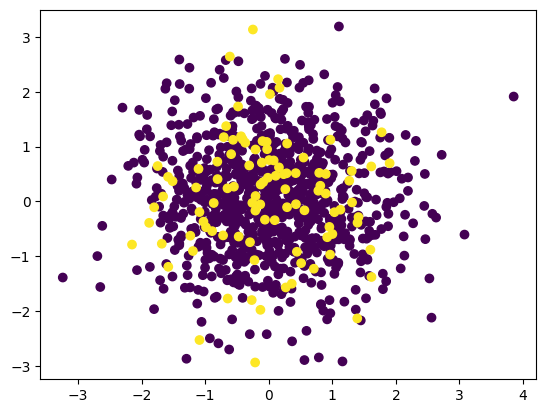

In [51]:
plt.scatter(df["feature_1"],df["feature_2"],c=df["target"])

In [54]:
from  imblearn.over_sampling import SMOTE

In [55]:
oversample = SMOTE()

In [58]:
(X,y) = oversample.fit_resample(df[["feature_1","feature_2"]],df["target"])


In [60]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1795    1
1796    1
1797    1
1798    1
1799    1
Name: target, Length: 1800, dtype: int64

In [61]:
oversample_df = pd.concat([X,y],axis = 1)

In [68]:
oversample_df["target"].value_counts()


target
0    900
1    900
Name: count, dtype: int64

In [71]:
df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64